# BeautifulSoup Documentation Analytics

A reproducible companion analysis for the final project.

## tl;dr

This notebook loads the three processed datasets, validates their schemas, answers the eight required and two additional analytical questions, and reproduces the four required charts. The concrete findings below are populated by executed cells.

## Context & Methods

Source: Beautiful Soup 4 documentation at https://www.crummy.com/software/BeautifulSoup/bs4/doc/. The pipeline downloads one HTML snapshot, parses it with `html.parser`, and extracts sections, links, and code examples.

### Key Assumptions

- Sections are defined by `h1`, `h2`, and `h3` headings.
- Code examples are represented by `pre` elements.
- Technical keywords use the curated BeautifulSoup/Python/HTML vocabulary in `src/analyzer.py`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from analyzer import (
    q1_total_sections, q2_highest_word_count_section,
    q3_most_code_examples_section, q4_most_links_section,
    q5_top10_keywords, q6_internal_external_links,
    q7_find_all_usage, q8_get_text_usage,
    q9_word_count_statistics, q10_bs4_method_usage_ratio,
)

## Data

### 1. Load and validate the processed datasets

In [2]:
processed_dir = PROJECT_ROOT / 'data' / 'processed'
sections_df = pd.read_csv(processed_dir / 'sections.csv', encoding='utf-8-sig')
links_df = pd.read_csv(processed_dir / 'links.csv', encoding='utf-8-sig')
code_examples_df = pd.read_csv(processed_dir / 'code_examples.csv', encoding='utf-8-sig')

expected_columns = {
    'sections': {'section_id', 'section_level', 'section_title', 'section_text', 'word_count', 'code_block_count', 'link_count'},
    'links': {'link_text', 'href', 'link_type', 'section_title'},
    'code_examples': {'example_id', 'section_title', 'code_text', 'line_count', 'contains_find_all', 'contains_find', 'contains_select', 'contains_get_text', 'contains_requests'},
}
datasets = {'sections': sections_df, 'links': links_df, 'code_examples': code_examples_df}
for name, frame in datasets.items():
    assert set(frame.columns) == expected_columns[name], f'Unexpected schema for {name}'
    assert not frame.isna().any().any(), f'Missing values found in {name}'

pd.DataFrame([
    {'dataset': name, 'rows': len(frame), 'columns': len(frame.columns)}
    for name, frame in datasets.items()
] )

,dataset,rows,columns
0,sections,113,7
1,links,504,4
2,code_examples,220,9


## Results

### 2. Answer all ten analytical questions

In [3]:
analysis_results = {
    'q1_total_sections': q1_total_sections(sections_df),
    'q2_highest_word_count_section': q2_highest_word_count_section(sections_df),
    'q3_most_code_examples_section': q3_most_code_examples_section(sections_df),
    'q4_most_links_section': q4_most_links_section(sections_df),
    'q5_top10_keywords': q5_top10_keywords(sections_df),
    'q6_internal_external_links': q6_internal_external_links(links_df),
    'q7_find_all_usage': q7_find_all_usage(code_examples_df),
    'q8_get_text_usage': q8_get_text_usage(code_examples_df),
    'q9_word_count_statistics': q9_word_count_statistics(sections_df),
    'q10_bs4_method_usage_ratio': q10_bs4_method_usage_ratio(code_examples_df),
}

answers = [
    ('Q1', 'Total sections', analysis_results['q1_total_sections']),
    ('Q2', 'Highest word count section', analysis_results['q2_highest_word_count_section']),
    ('Q3', 'Most code examples section', analysis_results['q3_most_code_examples_section']),
    ('Q4', 'Most links section', analysis_results['q4_most_links_section']),
    ('Q5', 'Top 10 technical keywords', analysis_results['q5_top10_keywords']),
    ('Q6', 'Internal and external links', analysis_results['q6_internal_external_links']),
    ('Q7', 'Examples using find_all()', analysis_results['q7_find_all_usage']),
    ('Q8', 'Examples using get_text()', analysis_results['q8_get_text_usage']),
    ('Q9*', 'Word-count statistics', analysis_results['q9_word_count_statistics']),
    ('Q10*', 'Examples using a BS4 search method', analysis_results['q10_bs4_method_usage_ratio']),
]
pd.DataFrame(answers, columns=['question_id', 'question', 'answer'])

,question_id,question,answer
0,Q1,Total sections,113
1,Q2,Highest word count section,"{'section_title': 'Multi-valued attributes', '..."
2,Q3,Most code examples section,"{'section_title': 'Multi-valued attributes', '..."
3,Q4,Most links section,"{'section_title': 'Table of Contents', 'link_c..."
4,Q5,Top 10 technical keywords,"[{'keyword': 'soup', 'frequency': 516}, {'keyw..."
5,Q6,Internal and external links,"{'internal_anchor': 470, 'external_link': 19}"
6,Q7,Examples using find_all(),39
7,Q8,Examples using get_text(),4
8,Q9*,Word-count statistics,"{'mean': 173.44247787610618, 'median': 139.0, ..."
9,Q10*,Examples using a BS4 search method,"{'total_code_examples': 220, 'examples_using_s..."


In [4]:
keyword_df = pd.DataFrame(analysis_results['q5_top10_keywords'])
keyword_df

,keyword,frequency
0,soup,516
1,tag,432
2,html,266
3,class,258
4,find,199
5,string,196
6,link,184
7,href,170
8,parser,151
9,beautifulsoup,149


### 3. Reproduce the four required charts

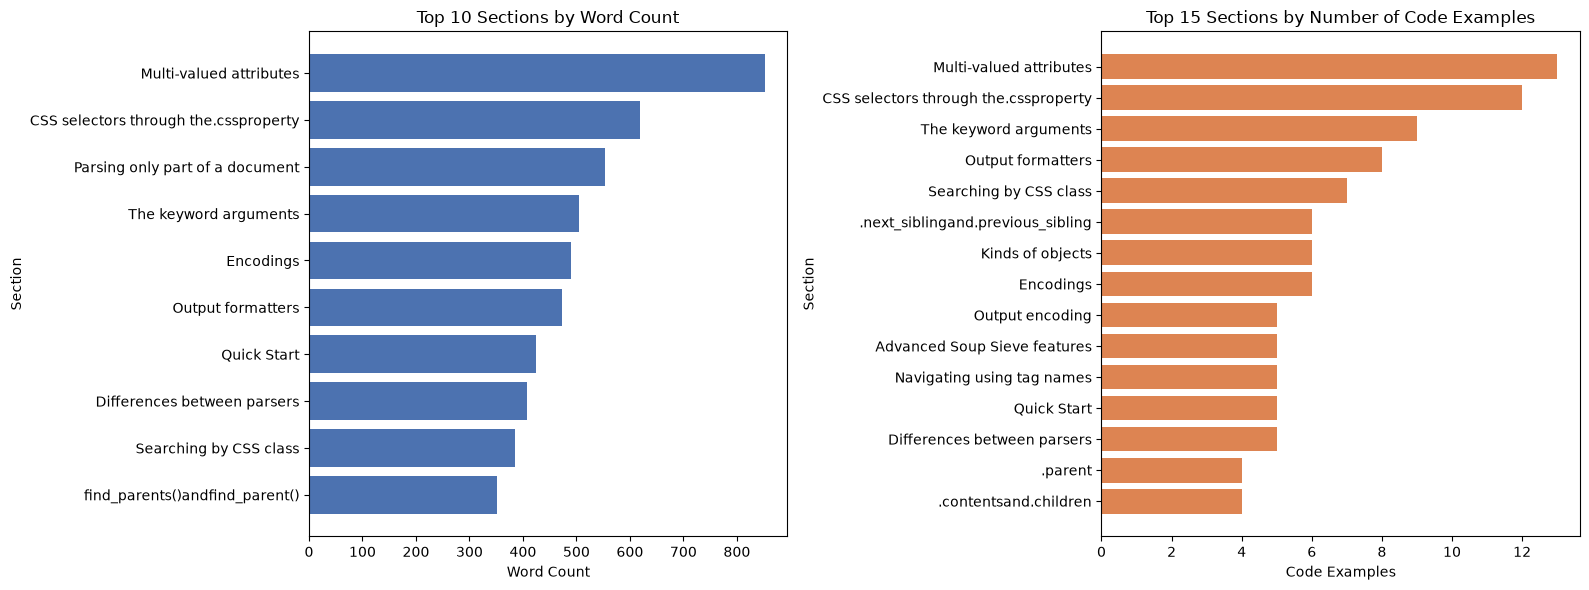

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_sections = sections_df.nlargest(10, 'word_count').sort_values('word_count')
axes[0].barh(top_sections['section_title'], top_sections['word_count'], color='#4C72B0')
axes[0].set(title='Top 10 Sections by Word Count', xlabel='Word Count', ylabel='Section')

code_counts = code_examples_df.groupby('section_title').size().nlargest(15).sort_values()
axes[1].barh(code_counts.index, code_counts.values, color='#DD8452')
axes[1].set(title='Top 15 Sections by Number of Code Examples', xlabel='Code Examples', ylabel='Section')
plt.tight_layout()
plt.show()

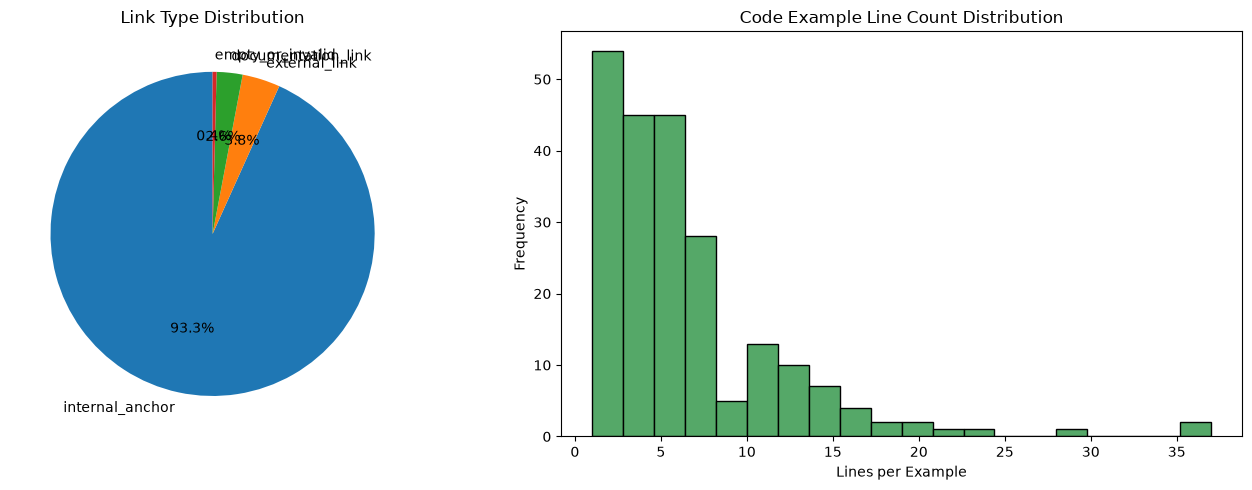

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
link_counts = links_df['link_type'].value_counts()
axes[0].pie(link_counts.values, labels=link_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Link Type Distribution')
axes[1].hist(code_examples_df['line_count'], bins=20, color='#55A868', edgecolor='black')
axes[1].set(title='Code Example Line Count Distribution', xlabel='Lines per Example', ylabel='Frequency')
plt.tight_layout()
plt.show()

## Takeaways

- The processed data contains 113 sections, 504 links, and 220 code examples.
- `Multi-valued attributes` is both the longest section and the section with the most code examples.
- Most extracted links are internal anchors, showing that the page relies heavily on in-page navigation.
- The code examples vary substantially in length, while only a subset uses the core `find_all`, `find`, or `select` search methods.
- Results describe a single documentation snapshot and may change when the source page is updated.